# **Урок 3**. Обучаем нейросети круто

В прошлом уроке мы с вами поработали над задачей классификации дорожных знаков на 48 классов. Для этой задачи мы не просто файн-тюнили последний слой, а тюнили всю цель целиком - и получали существенно более крутые результаты!

Но, как мы знаем из теоретической части, исследователи придумали ещё кучу техник, которые позволяют улучшить процесс обучения сети. Давайте сегодня попробуем добавить часть техник в наш код и проверим, действительно ли станет лучше. 

## **План**


1. Воспроизведем результат, который получили в прошлый раз
2. Добавляем аугментации в наш эксперимент
3. Настраиваем ```LR Scheduler```
4. Играем с ```batch size```
5. Выравниваем семплирование данных

Погнали!

## **1. Воспроизведем то, что было**

Напоминаю, что архив с датасетом можно скачать по [cсылке](https://disk.yandex.ru/d/RVaIyjVsxLDjYAс), а все строчки кода для монтирования диска, как и раньше, в следующих двух клетках.

In [ ]:
# Если вы работаете в colab, раскомментируйте эти строчки!

# прикручиваем свой гуглдиск, куда закинули архив с данными
# from google.colab import drive
# drive.mount("/content/gdrive/My Drive/", force_remount=True)

In [ ]:
# Если вы работаете в colab, раскомментируйте эти строчки и впишите свои пути

# указываем путь к данным на диске, например, у меня такой 
# разархивируем архив с данными, флаг -q - не выводить логи
# !unzip -q '/content/gdrive/My Drive/karpov.courses/lesson_2/signs.zip' -d './'

# После разархивации в директории с нашим ноутбуком появится папка signs, она-то нам и нужна

Ниже весь код для обучения, который мы уже знаем. На этот раз в нем не будет таких подробных комментариев, чтобы не загромождать его. 

In [1]:
# импортируем всё необходимое
import os
import cv2
import PIL
import glob
import wandb
import random

import numpy as np
import pandas as pd
import seaborn as sn
import typing as tp
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torch.nn.functional as F

import torchvision
import torchvision.models as models
import torchvision.transforms.v2 as transforms

from dataclasses import dataclass
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from torch.utils.data import Dataset, DataLoader

wandb.require("core")

wandb: WARNING `wandb.require('core')` is a no-op as it is now the default behavior.


In [2]:
# тот же Датасет для знаков, что и раньше
class SignDataset(data.Dataset): 
    """Это наш датасет

    Какие у него аргументы:
        dataframe: раз уж сделали датафрейм, будем его тут юзать
        transform: преобразование, которое будем применять к картинкам
    """
    def __init__(self, dataframe, transform=None):
        self.imlist = dataframe 
        self.transform = transform

    def __getitem__(self, index):
        impath, target = self.imlist.loc[index]

        if not os.path.exists(impath): 
            print('No file ', impath)
            pass

        img = PIL.Image.open(impath).convert('RGB')
        img = self.transform(img)

        return img, target, impath

    def __len__(self):
        return len(self.imlist)
    
    
# функция для разнормализации картинки и её отрисовки
def myshow(img):
    img = img * 0.3 + 0.3
    npimg = img.detach().numpy()
    fig = plt.figure(figsize=(10, 10))
    plt.imshow(npimg.transpose(1, 2, 0))

In [3]:
# устанавливаем девайс
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print('Device: ', device)

Device:  cuda


In [4]:
# фиксируем сиды
def enable_determinism():
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    torch.use_deterministic_algorithms(True) # на этот раз зафиксируем алгоритмы, чтобы изменения точно не были случайными

def fix_seeds(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.mps.manual_seed(seed)
    
def seed_worker(_):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [5]:
# функция для обучения/тестирования
def run_epoch(epoch, net, loader, criterion, optimizer, device, is_train):
    """
    Training and evaluaton loop over samples
    
    Args:
        train_mode (bool): True for train mode
    """
    if is_train:
        net.train()
    else:
        net.eval()
        
    running_loss = 0.0
    correct = 0.0
    total = 0.0
    all_preds = []
    all_labels = []

    for i, data in enumerate(loader):
        images, labels, _= data
        images, labels = images.to(device), labels.to(device)

        outputs = net(images)
        loss = criterion(outputs, labels)

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds = np.concatenate((all_preds, predicted.cpu().numpy()))
        all_labels = np.concatenate((all_labels, labels.cpu().numpy()))
    
    acc = (all_preds == all_labels).sum()/len(all_preds)
    bal_acc = balanced_accuracy_score(all_labels, all_preds)

    print('Loss: {:.3f}, accuracy: {:.3f}, balanced: {:.3f}'.format(running_loss / (i + 1), acc * 100.0, bal_acc * 100.0))
    if is_train:
        wandb.log({'train loss': running_loss / (i + 1)}, step=epoch)
        wandb.log({'train accuracy': acc * 100.0}, step=epoch)
        wandb.log({'train balanced accuracy': bal_acc * 100.0}, step=epoch)
    else:
        wandb.log({'test loss': running_loss / (i + 1)}, step=epoch)
        wandb.log({'test accuracy': acc * 100.0}, step=epoch)
        wandb.log({'test balanced accuracy': bal_acc * 100.0}, step=epoch)
        
    return all_preds, all_labels

In [6]:
# готовим датафреймы
all_train_files = sorted(glob.glob('/kaggle/input/datasets/andreykurdyubov/signs-cv2/signs/TRAIN/*/*'))
all_test_files = sorted(glob.glob('/kaggle/input/datasets/andreykurdyubov/signs-cv2/signs/TEST/*/*'))

train_classes = [int(x.split('/')[-2]) for x in all_train_files]
test_classes = [int(x.split('/')[-2]) for x in all_test_files]

train_df = pd.DataFrame(zip(all_train_files, train_classes), columns=['imname', 'class'])
test_df = pd.DataFrame(zip(all_test_files, test_classes), columns=['imname', 'class'])

In [7]:
# конфиг с основными гиперпараметрами
@dataclass
class Config:
    seed: int = 24
    batch_size: int = 32
    img_size: int = 64
    n_epochs: int = 10
    lr: float = 1e-4

# не забывайте, что фиксировать заново сиды и создавать даталоадеры с ними нужно каждый раз, если хотите воспроизводимости
config = Config()
enable_determinism()
fix_seeds(config.seed)

generator = torch.Generator()
generator.manual_seed(config.seed)

In [8]:
transform = transforms.Compose([
    transforms.Resize((config.img_size, config.img_size), antialias=True),
    transforms.PILToTensor(),
    transforms.ToDtype(dtype=torch.float32, scale=True),
    transforms.Normalize([0.3, 0.3, 0.3], [0.3, 0.3, 0.3])
])

trainset = SignDataset(dataframe=train_df, transform=transform)
testset = SignDataset(dataframe=test_df, transform=transform)

trainloader = DataLoader(
    trainset, 
    batch_size=config.batch_size, 
    num_workers=4, 
    shuffle=True, 
    pin_memory=True,
    drop_last=True,
    worker_init_fn=seed_worker,
    generator=generator,
)

testloader = DataLoader(
    testset, 
    batch_size=config.batch_size, 
    num_workers=4, 
    pin_memory=True
)

In [9]:
# берем модельку
net = models.resnet50(weights='DEFAULT')
net.fc = nn.Linear(net.fc.in_features, 48)
net = net.to(device)

optimizer = torch.optim.Adam(net.parameters(), lr=config.lr)
criterion = nn.CrossEntropyLoss()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 202MB/s]


In [13]:
# инициализируем эксперимент в wandb
wandb.init(
    project="lesson-3", 
    name="recap_resnet_50", 
    config=config.__dict__
)

# и погнали итерироваться
for epoch in range(config.n_epochs):
    # training
    print("Training epoch: ", epoch + 1, "/", config.n_epochs)
    _, _ = run_epoch(epoch, net, trainloader, criterion, optimizer, device, is_train=True)

    # validation
    print('Validation')
    with torch.no_grad():
        _, _ = run_epoch(epoch, net, testloader, criterion, optimizer, device, is_train=False)
    print('----------------------')

print('Finished training! Enjoy your results!')

wandb.finish()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: a-s-kurdyubov (a-s-kurdyubov-spbu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Training epoch:  1 / 10
Loss: 2.749, accuracy: 42.969, balanced: 25.244
Validation
Loss: 2.378, accuracy: 44.265, balanced: 26.968
----------------------
Training epoch:  2 / 10
Loss: 0.798, accuracy: 83.371, balanced: 58.583
Validation
Loss: 1.519, accuracy: 63.128, balanced: 50.400
----------------------
Training epoch:  3 / 10
Loss: 0.255, accuracy: 95.703, balanced: 86.534
Validation
Loss: 1.077, accuracy: 70.047, balanced: 61.703
----------------------
Training epoch:  4 / 10
Loss: 0.094, accuracy: 98.214, balanced: 95.202
Validation
Loss: 0.895, accuracy: 74.882, balanced: 69.002
----------------------
Training epoch:  5 / 10
Loss: 0.046, accuracy: 99.219, balanced: 98.274
Validation
Loss: 0.878, accuracy: 75.450, balanced: 69.178
----------------------
Training epoch:  6 / 10
Loss: 0.021, accuracy: 99.833, balanced: 99.335
Validation
Loss: 0.804, accuracy: 78.009, balanced: 72.579
----------------------
Training epoch:  7 / 10
Loss: 0.012, accuracy: 99.888, balanced: 99.757
Vali

test accuracy,▁▅▆▇▇█████
test balanced accuracy,▁▅▆▇▇█████
test loss,█▄▂▂▁▁▁▁▁▁
train accuracy,▁▆▇███████
train balanced accuracy,▁▄▇███████
train loss,█▃▂▁▁▁▁▁▁▁
test accuracy,78.76777
test balanced accuracy,73.7245
test loss,0.79513
train accuracy,100
train balanced accuracy,100


Итак, мы запустили обучение с теми же параметрами, что и на прошлом уроке. 
Как видим, результат уже не тот же, что был в прошлый раз (это всё недетерминированные алгоритмы ууу). 

Но это наш старт. Теперь будем его улучшать. 

## **2. Добавляем аугментации**

Давайте вспомним, как выглядят у нас сейчас данные на обучении. 

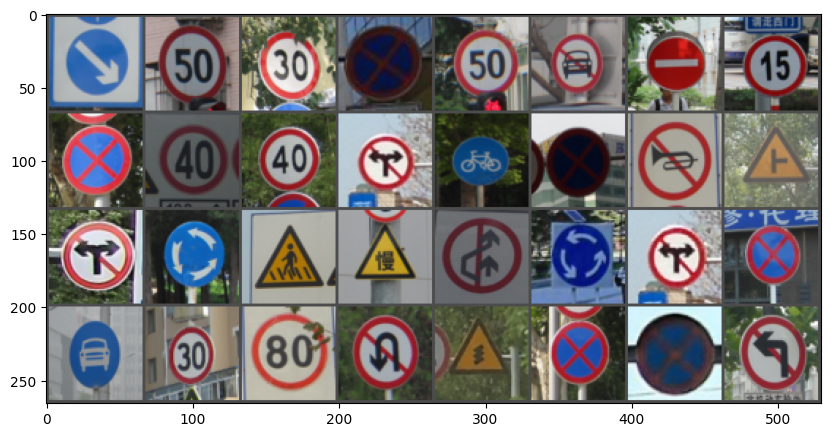

In [14]:
# мы так уже делали в прошлом уроке: берем батч, разнормализовываем, визуализируем
trainiter = iter(trainloader)
images, labels, impaths = next(trainiter)
myshow(torchvision.utils.make_grid(images))

Очень скучно и очень просто. Давайте что-то поинтереснее сделаем. 

Например, используем сразу целый пайплайн аугментаций. Мой любимый - ```TrivialAugment```. 

In [15]:
@dataclass
class Config:
    seed: int = 24
    batch_size: int = 32
    img_size: int = 64
    n_epochs: int = 10
    lr: float = 1e-4

config = Config()
enable_determinism()
fix_seeds(config.seed)
generator = torch.Generator()
generator.manual_seed(config.seed)

In [16]:
# как устроен RandomResizedCrop -> https://pytorch.org/vision/main/generated/torchvision.transforms.v2.RandomResizedCrop.html
# дока по TrivialAugment -> https://pytorch.org/vision/main/generated/torchvision.transforms.TrivialAugmentWide.html

# теперь трансформов у нас будет два - отдельно на трейн и тест

# на трейне мы издеваемся над картинками
transform_train = transforms.Compose([
    transforms.RandomResizedCrop(size=(config.img_size, config.img_size), scale=(0.5, 1.0), antialias=True),
    transforms.TrivialAugmentWide(),
    transforms.PILToTensor(),
    transforms.ToDtype(dtype=torch.float32, scale=True),
    transforms.Normalize([0.3, 0.3, 0.3], [0.3, 0.3, 0.3])
])

# а на тесте нет, делаем только необходимый минимум
transform_test = transforms.Compose([
    transforms.Resize((config.img_size, config.img_size), antialias=True),
    transforms.PILToTensor(),
    transforms.ToDtype(dtype=torch.float32, scale=True),
    transforms.Normalize([0.3, 0.3, 0.3], [0.3, 0.3, 0.3])
])

In [18]:
# создаем датасеты с новыми трансформами
trainset = SignDataset(dataframe=train_df, transform=transform_train)
testset = SignDataset(dataframe=test_df, transform=transform_test)

# и соответственные даталоадеры
trainloader = DataLoader(
    trainset, 
    batch_size=config.batch_size, 
    num_workers=4, 
    shuffle=True, 
    pin_memory=True,
    drop_last=True,
    worker_init_fn=seed_worker,
    generator=generator,
)

testloader = DataLoader(
    testset, 
    batch_size=config.batch_size, 
    num_workers=4, 
    pin_memory=True
)

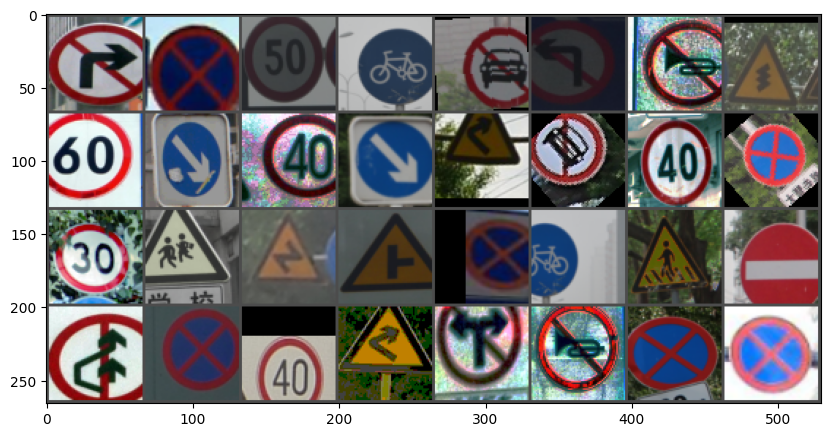

In [19]:
# посмотрим, как выглядит трейн теперь
trainiter = iter(trainloader)
images, labels, impaths = next(trainiter)
myshow(torchvision.utils.make_grid(images))

Намного веселее :) Давайте учить. 

In [20]:
net = models.resnet50(weights='DEFAULT')
net.fc = nn.Linear(net.fc.in_features, 48)
net = net.to(device)

optimizer = torch.optim.Adam(net.parameters(), lr=config.lr)
criterion = nn.CrossEntropyLoss()

wandb.init(
    project="lesson-3", 
    name="trivial_and_rrc", 
    config=config.__dict__
)

for epoch in range(config.n_epochs):
    print("Training epoch: ", epoch + 1, "/", config.n_epochs)
    _, _ = run_epoch(epoch, net, trainloader, criterion, optimizer, device, is_train=True)

    print('Validation')
    with torch.no_grad():
        _, _ = run_epoch(epoch, net, testloader, criterion, optimizer, device, is_train=False)
    print('----------------------')

print('Finished training! Enjoy your results!')

wandb.finish()

Training epoch:  1 / 10
Loss: 3.209, accuracy: 26.339, balanced: 13.617
Validation
Loss: 2.789, accuracy: 34.597, balanced: 20.569
----------------------
Training epoch:  2 / 10
Loss: 1.657, accuracy: 61.384, balanced: 34.649
Validation
Loss: 1.684, accuracy: 58.009, balanced: 40.299
----------------------
Training epoch:  3 / 10
Loss: 0.873, accuracy: 77.846, balanced: 53.745
Validation
Loss: 1.115, accuracy: 68.815, balanced: 53.711
----------------------
Training epoch:  4 / 10
Loss: 0.559, accuracy: 84.877, balanced: 65.885
Validation
Loss: 0.836, accuracy: 74.597, balanced: 62.951
----------------------
Training epoch:  5 / 10
Loss: 0.382, accuracy: 89.844, balanced: 77.632
Validation
Loss: 0.701, accuracy: 77.346, balanced: 69.903
----------------------
Training epoch:  6 / 10
Loss: 0.285, accuracy: 92.690, balanced: 84.059
Validation
Loss: 0.600, accuracy: 81.137, balanced: 76.201
----------------------
Training epoch:  7 / 10
Loss: 0.236, accuracy: 93.694, balanced: 86.130
Vali

test accuracy,▁▄▆▇▇▇████
test balanced accuracy,▁▃▅▆▆▇▇███
test loss,█▅▃▂▂▁▁▁▁▁
train accuracy,▁▅▆▇▇█████
train balanced accuracy,▁▃▅▆▇▇▇███
train loss,█▄▃▂▂▁▁▁▁▁
test accuracy,84.73934
test balanced accuracy,83.69654
test loss,0.48086
train accuracy,96.20536
train balanced accuracy,92.32874


Супер! 

Сперва по графикам казалось, что учимся мы намного хуже, ведь точность и лосс на трейне не так хорошо прогрессировали. 

Однако отслеживание результатов на тесте показывает совсем другую картину: благодаря аугментациям мы значительно снизили переобучение - теперь на трейне мы не упираемся в 100%-ую точность, ей ещё есть куда учиться, а качество на тесте растет активнее, в итоге получилось значительно выше -  ```accuracy: 78.86% -> 83.69%```

Давайте попробуем сюда же добавить ```RandomErasing``` для регуляризации процесса. 

Документация: https://pytorch.org/vision/main/generated/torchvision.transforms.v2.RandomErasing.html

In [41]:
@dataclass
class Config:
    seed: int = 24
    batch_size: int = 32
    img_size: int = 64
    n_epochs: int = 10
    lr: float = 1e-4

config = Config()
enable_determinism()
fix_seeds(config.seed)
generator = torch.Generator()
generator.manual_seed(config.seed)

In [42]:
# RandomErasing мы добавляем уже после нормализации, по умолчанию он будет заполнять случайные прямоугольники на картинке нулями
transform_train = transforms.Compose([
    transforms.RandomResizedCrop(size=(config.img_size, config.img_size), scale=(0.5, 1.0), antialias=True),
    transforms.TrivialAugmentWide(),
    transforms.PILToTensor(),
    transforms.ToDtype(dtype=torch.float32, scale=True),
    transforms.Normalize([0.3, 0.3, 0.3], [0.3, 0.3, 0.3]),
    transforms.RandomErasing(),
])

trainset = SignDataset(dataframe=train_df, transform=transform_train)

# и соответственные даталоадеры
trainloader = DataLoader(trainset, batch_size=config.batch_size, num_workers=4, 
    shuffle=True, pin_memory=True, drop_last=True, 
    worker_init_fn=seed_worker, generator=generator,
)

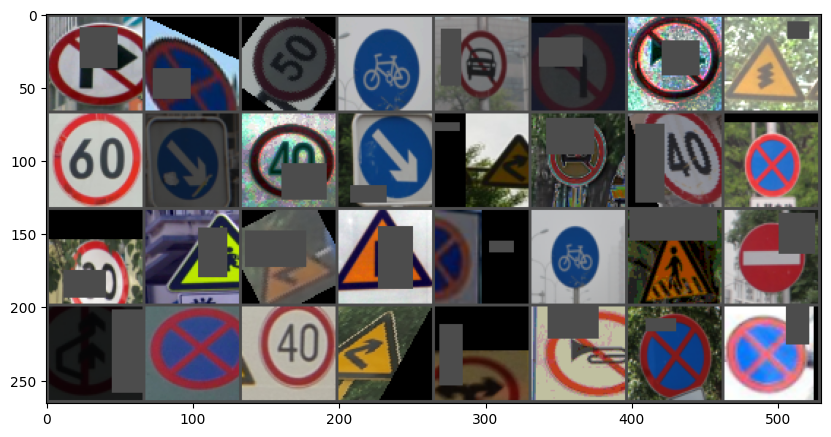

In [43]:
# ну что там, давайте посмотрим
trainiter = iter(trainloader)
images, labels, impaths = next(trainiter)
myshow(torchvision.utils.make_grid(images))

Прямоугольники тут серые из-за разнормализации, для сетки там будут нули, и они будут как будто черные. 

In [44]:
net = models.resnet50(weights='DEFAULT')
net.fc = nn.Linear(net.fc.in_features, 48)
net = net.to(device)

optimizer = torch.optim.Adam(net.parameters(), lr=config.lr)
criterion = nn.CrossEntropyLoss()

wandb.init(
    project="lesson-3", 
    name="trivial_rrc_erase5", 
    config=config.__dict__
)

for epoch in range(config.n_epochs):
    print("Training epoch: ", epoch + 1, "/", config.n_epochs)
    _, _ = run_epoch(epoch, net, trainloader, criterion, optimizer, device, is_train=True)

    print('Validation')
    with torch.no_grad():
        _, _ = run_epoch(epoch, net, testloader, criterion, optimizer, device, is_train=False)
    print('----------------------')

print('Finished training! Enjoy your results!')

wandb.finish()

Training epoch:  1 / 10
Loss: 3.313, accuracy: 22.935, balanced: 11.252
Validation
Loss: 2.806, accuracy: 33.460, balanced: 19.292
----------------------
Training epoch:  2 / 10
Loss: 1.831, accuracy: 58.036, balanced: 31.952
Validation
Loss: 1.712, accuracy: 55.261, balanced: 36.662
----------------------
Training epoch:  3 / 10
Loss: 1.088, accuracy: 70.592, balanced: 46.571
Validation
Loss: 1.194, accuracy: 65.592, balanced: 50.016
----------------------
Training epoch:  4 / 10
Loss: 0.771, accuracy: 79.241, balanced: 58.451
Validation
Loss: 0.970, accuracy: 70.047, balanced: 55.923
----------------------
Training epoch:  5 / 10
Loss: 0.617, accuracy: 82.087, balanced: 64.697
Validation
Loss: 0.883, accuracy: 71.374, balanced: 59.381
----------------------
Training epoch:  6 / 10
Loss: 0.530, accuracy: 83.203, balanced: 67.422
Validation
Loss: 0.767, accuracy: 75.355, balanced: 68.560
----------------------
Training epoch:  7 / 10
Loss: 0.418, accuracy: 87.891, balanced: 79.422
Vali

test accuracy,▁▄▆▇▇▇████
test balanced accuracy,▁▃▅▅▆▇▇███
test loss,█▄▃▂▂▁▁▁▁▁
train accuracy,▁▅▆▇▇▇████
train balanced accuracy,▁▃▄▅▆▆▇███
train loss,█▅▃▂▂▂▁▁▁▁
test accuracy,79.62085
test balanced accuracy,77.38688
test loss,0.66455
train accuracy,90.51339
train balanced accuracy,84.49959


Что мы тут видим? На первый взгляд, стало хуже: графики все шли ниже, чем у прошлого эксперимента, а финальная точность получилась хуже. 

На самом же деле, сети стало просто сложнее учиться, мы видим, что на трейне она доходит только ```91%``` точности (раньше было вообще ```100%```!), тренд обучения восходящий, а значит, нам надо поучить ещё. Не забывайте, что чем жестче аугментации (и сложнее задача обучения), тем дольше надо учить сеть. 

In [34]:
@dataclass
class Config:
    seed: int = 24
    batch_size: int = 32
    img_size: int = 64
    n_epochs: int = 10 # увеличим число эпох на 30%
    lr: float = 1e-4

config = Config()
enable_determinism()
fix_seeds(config.seed)
generator = torch.Generator()
generator.manual_seed(config.seed)

trainloader = DataLoader(trainset, batch_size=config.batch_size, num_workers=4, 
    shuffle=True, pin_memory=True, drop_last=True, 
    worker_init_fn=seed_worker, generator=generator,
)

In [35]:
net = models.resnet50(weights='DEFAULT')
net.fc = nn.Linear(net.fc.in_features, 48)
net = net.to(device)

optimizer = torch.optim.Adam(net.parameters(), lr=config.lr)
criterion = nn.CrossEntropyLoss()

wandb.init(
    project="lesson-3", 
    name="trivial_rrc_erase2", 
    config=config.__dict__
)

for epoch in range(config.n_epochs):
    print("Training epoch: ", epoch + 1, "/", config.n_epochs)
    _, _ = run_epoch(epoch, net, trainloader, criterion, optimizer, device, is_train=True)

    print('Validation')
    with torch.no_grad():
        _, _ = run_epoch(epoch, net, testloader, criterion, optimizer, device, is_train=False)
    print('----------------------')

print('Finished training! Enjoy your results!')

wandb.finish()

Training epoch:  1 / 10
Loss: 3.329, accuracy: 21.652, balanced: 10.893
Validation
Loss: 2.798, accuracy: 34.882, balanced: 20.653
----------------------
Training epoch:  2 / 10
Loss: 1.904, accuracy: 55.525, balanced: 30.861
Validation
Loss: 1.704, accuracy: 55.071, balanced: 36.241
----------------------
Training epoch:  3 / 10
Loss: 1.130, accuracy: 71.205, balanced: 45.215
Validation
Loss: 1.235, accuracy: 65.213, balanced: 48.756
----------------------
Training epoch:  4 / 10
Loss: 0.799, accuracy: 76.897, balanced: 55.608
Validation
Loss: 0.943, accuracy: 72.322, balanced: 57.616
----------------------
Training epoch:  5 / 10
Loss: 0.625, accuracy: 82.087, balanced: 63.874
Validation
Loss: 0.789, accuracy: 75.829, balanced: 64.865
----------------------
Training epoch:  6 / 10
Loss: 0.499, accuracy: 84.319, balanced: 68.184
Validation
Loss: 0.659, accuracy: 79.716, balanced: 70.372
----------------------
Training epoch:  7 / 10
Loss: 0.442, accuracy: 87.667, balanced: 77.294
Vali

test accuracy,▁▄▅▆▇▇▇███
test balanced accuracy,▁▃▄▅▆▇▇███
test loss,█▅▃▂▂▂▂▁▁▁
train accuracy,▁▄▆▇▇▇████
train balanced accuracy,▁▃▄▅▆▆▇▇██
train loss,█▅▃▂▂▁▁▁▁▁
test accuracy,84.2654
test balanced accuracy,81.88872
test loss,0.48563
train accuracy,90.84821
train balanced accuracy,84.51962


Отлично! 

Поучив подольше, мы получили в некоторых точках результат лучше (был ниже ```loss``` на тесте и выше точность, мы могли бы его зафиксировать, просто взяв нужный чекпоинт), но после 11-й эпохи прогресс ухудшился - loss подрос, а точность упала, как будто мы дошли до минимума, а потом начали из него выходить. 

Это верный знак того, что нам надо настраивать ```learning rate```. Этим и займемся дальше :)

А тут давайте срезюмируем:
- добавление пайплайна ```TrivialAugment``` сразу дало нам прирост в обучении, мы порадовались
- добавление RandomErasing несколько снизило финальные метрики, так как задача стала сложнее. Мы сделали вывод, что надо учить подольше
- мы стали учить подольше, ещё чуть подросли, но в конце обучения видим, что поведение метрик нестабильно, поэтому хотим его стабилизироваться за счет расписания для ```lr```.

## **3. Добавляем LR Scheduler**

С шедулерами и их представлением в коде вы уже знакомы из урока 3 Базы DL. Там вы использовали ```ExponentialLR```.

В целом все шедулеры (```StepLR```, ```ExponentialLR```, ```LinearLR```) должны делать шаг (обновлять ```lr```) после эпохи обучения, либо после нескольких эпох. У вас был более экзотический пример - когда шаг делался после каждых ```eval_every``` итераций. 

В этом плане от всех отличается ```CosineAnnealingLR```, который делает шаг **каждую** итерацию. 

Давайте тут сравним два шедулера: ```StepLR``` и ```CosineAnnealingLR```.

In [11]:
@dataclass
class Config:
    seed: int = 24
    batch_size: int = 32
    img_size: int = 64
    n_epochs: int = 13
    lr: float = 1e-4
    scheduler_type: tp.Literal['exp', 'step', 'cosine'] | None = 'step'

config = Config()
enable_determinism()
fix_seeds(config.seed)
generator = torch.Generator()
generator.manual_seed(config.seed)

trainloader = DataLoader(trainset, batch_size=config.batch_size, num_workers=4, 
    shuffle=True, pin_memory=True, drop_last=True, 
    worker_init_fn=seed_worker, generator=generator,
)

Документация по ```CosineAnnealingLR``` [живет тут](https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.CosineAnnealingLR.html).

In [30]:
def get_scheduler(config, optimizer, step=None, gamma=None):
    if config.scheduler_type == 'exp':
        return optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)
    elif config.scheduler_type == 'step':
        return optim.lr_scheduler.StepLR(optimizer, step_size=step, gamma=gamma)
    elif config.scheduler_type == 'cosine':
        T_max = config.n_epochs * len(trainloader) 
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=T_max)
    else:
        return None

In [13]:
# сеть задается независимо
net = models.resnet50(weights='DEFAULT')
net.fc = nn.Linear(net.fc.in_features, 48)
net = net.to(device)

# оптимайзер привязан к сети
optimizer = torch.optim.Adam(net.parameters(), lr=config.lr)

# scheduler привязан к оптимайзеру
scheduler = get_scheduler(config, optimizer, step=11, gamma=0.1)

Нам придется переписать наш ```train loop```, добавив в него шаги шедулера:

In [33]:
# функция для обучения/тестирования
def run_epoch_v2(epoch, net, loader, criterion, optimizer, scheduler, device, is_train):
    """
    Training and evaluaton loop over samples
    
    Args:
        train_mode (bool): True for train mode
    """
    if is_train:
        net.train()
    else:
        net.eval()
        
    running_loss = 0.0
    correct = 0.0
    total = 0.0
    all_preds = []
    all_labels = []
    lr = config.lr

    for i, data in enumerate(loader):
        images, labels, _= data
        images, labels = images.to(device), labels.to(device)

        outputs = net(images)
        loss = criterion(outputs, labels)

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            # если шедулер задан и он cosine, то апдейтим его каждую итерацию
            if (scheduler is not None) and (config.scheduler_type == 'cosine'):
                scheduler.step()
                lr = scheduler.get_last_lr()[0]

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds = np.concatenate((all_preds, predicted.cpu().numpy()))
        all_labels = np.concatenate((all_labels, labels.cpu().numpy()))


    acc = (all_preds == all_labels).sum()/len(all_preds)
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    
    print('Loss: {:.3f}, accuracy: {:.3f}, balanced: {:.3f}'.format(running_loss / (i + 1), acc * 100.0, bal_acc * 100.0))
    
    if is_train:
        # если шедулер задан и он не cosine, то апдейтим его после эпохи обучения
        if (scheduler is not None) and (config.scheduler_type != 'cosine'): 
            scheduler.step()
            lr = scheduler.get_last_lr()[0]
        
        wandb.log({'lr': lr}, step=epoch)    
        wandb.log({'train loss': running_loss / (i + 1)}, step=epoch)
        wandb.log({'train accuracy': acc * 100.0}, step=epoch)
        wandb.log({'train balanced accuracy': bal_acc * 100.0}, step=epoch)
    else:
        wandb.log({'test loss': running_loss / (i + 1)}, step=epoch)
        wandb.log({'test accuracy': acc * 100.0}, step=epoch)
        wandb.log({'test balanced accuracy': bal_acc * 100.0}, step=epoch)
        
        
    return all_preds, all_labels

In [15]:
wandb.init(
    project='lesson-3', 
    name='step_scheduler', 
    config=config.__dict__
)


for epoch in range(config.n_epochs):
    print("Training epoch: ", epoch + 1, "/", config.n_epochs)
    _, _ = run_epoch_v2(epoch, net, trainloader, criterion, optimizer, scheduler, device, is_train=True)

    print('Validation')
    with torch.no_grad():
        _, _ = run_epoch_v2(epoch, net, testloader, criterion, optimizer, scheduler, device, is_train=False)
    print('----------------------')

print('Finished training! Enjoy your results!')

wandb.finish()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: a-s-kurdyubov (a-s-kurdyubov-spbu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Training epoch:  1 / 13
Loss: 2.749, accuracy: 42.969, balanced: 25.244
Validation
Loss: 2.378, accuracy: 44.265, balanced: 26.968
----------------------
Training epoch:  2 / 13
Loss: 0.798, accuracy: 83.371, balanced: 58.583
Validation
Loss: 1.519, accuracy: 63.128, balanced: 50.400
----------------------
Training epoch:  3 / 13
Loss: 0.255, accuracy: 95.703, balanced: 86.534
Validation
Loss: 1.077, accuracy: 70.047, balanced: 61.703
----------------------
Training epoch:  4 / 13
Loss: 0.094, accuracy: 98.214, balanced: 95.202
Validation
Loss: 0.895, accuracy: 74.882, balanced: 69.002
----------------------
Training epoch:  5 / 13
Loss: 0.046, accuracy: 99.219, balanced: 98.274
Validation
Loss: 0.878, accuracy: 75.450, balanced: 69.178
----------------------
Training epoch:  6 / 13
Loss: 0.021, accuracy: 99.833, balanced: 99.335
Validation
Loss: 0.804, accuracy: 78.009, balanced: 72.579
----------------------
Training epoch:  7 / 13
Loss: 0.012, accuracy: 99.888, balanced: 99.757
Vali

lr,██████████▁▁▁
test accuracy,▁▅▆▇▇████████
test balanced accuracy,▁▄▆▇▇████████
test loss,█▄▂▂▁▁▁▁▁▁▁▁▁
train accuracy,▁▆▇██████████
train balanced accuracy,▁▄▇██████████
train loss,█▃▂▁▁▁▁▁▁▁▁▁▁
lr,1e-05
test accuracy,78.29384
test balanced accuracy,73.87836
test loss,0.82406


Супер, мы ещё чуть-чуть, но подросли. 

Честно говоря, такой результат получился не сразу, я перебрала несколько ```StepLR``` стратегий, прежде чем финально сделала для вас эту. Надо было перебирать разные варианты ```step``` и ```gamma``` для ```scheduler```-а. Это мне в них всех и не нравится, и так слишком много всего перебирать приходится. 

По этой причине я и люблю ```Cosine``` стратегию, где надо задать только один параметр - начальный ```lr```, который будет постепенно угасать до 0. 

In [17]:
@dataclass
class Config:
    seed: int = 24
    batch_size: int = 32
    img_size: int = 64
    n_epochs: int = 13
    lr: float = 1e-4
    scheduler_type: tp.Literal['exp', 'step', 'cosine'] | None = 'cosine'

config = Config()
enable_determinism()
fix_seeds(config.seed)
generator = torch.Generator()
generator.manual_seed(config.seed)

trainloader = DataLoader(trainset, batch_size=config.batch_size, num_workers=4, 
    shuffle=True, pin_memory=True, drop_last=True, 
    worker_init_fn=seed_worker, generator=generator,
)

In [18]:
net = models.resnet50(weights='DEFAULT')
net.fc = nn.Linear(net.fc.in_features, 48)
net = net.to(device)

optimizer = torch.optim.Adam(net.parameters(), lr=config.lr)
scheduler = get_scheduler(config, optimizer)

In [19]:
wandb.init(
    project='lesson-3', 
    name='cosine_scheduler', 
    config=config.__dict__
)


for epoch in range(config.n_epochs):
    # training
    print("Training epoch: ", epoch + 1, "/", config.n_epochs)
    _, _ = run_epoch_v2(epoch, net, trainloader, criterion, optimizer, scheduler, device, is_train=True)

    # validation
    print('Validation')
    with torch.no_grad():
        _, _ = run_epoch_v2(epoch, net, testloader, criterion, optimizer, scheduler, device, is_train=False)
    print('----------------------')

print('Finished training! Enjoy your results!')

wandb.finish()

Training epoch:  1 / 13
Loss: 2.783, accuracy: 43.638, balanced: 25.984
Validation
Loss: 2.444, accuracy: 44.929, balanced: 27.839
----------------------
Training epoch:  2 / 13
Loss: 0.839, accuracy: 81.808, balanced: 55.303
Validation
Loss: 1.489, accuracy: 61.327, balanced: 45.500
----------------------
Training epoch:  3 / 13
Loss: 0.283, accuracy: 95.145, balanced: 83.488
Validation
Loss: 1.127, accuracy: 70.711, balanced: 59.215
----------------------
Training epoch:  4 / 13
Loss: 0.112, accuracy: 97.712, balanced: 92.611
Validation
Loss: 0.968, accuracy: 73.081, balanced: 64.415
----------------------
Training epoch:  5 / 13
Loss: 0.060, accuracy: 98.996, balanced: 97.359
Validation
Loss: 0.926, accuracy: 74.502, balanced: 67.243
----------------------
Training epoch:  6 / 13
Loss: 0.028, accuracy: 99.721, balanced: 99.254
Validation
Loss: 0.842, accuracy: 76.398, balanced: 69.615
----------------------
Training epoch:  7 / 13
Loss: 0.018, accuracy: 100.000, balanced: 100.000
Va

lr,██▇▇▆▅▄▃▃▂▁▁▁
test accuracy,▁▅▇▇█████████
test balanced accuracy,▁▄▆▇▇████████
test loss,█▄▂▂▁▁▁▁▁▁▁▁▁
train accuracy,▁▆▇██████████
train balanced accuracy,▁▄▆▇█████████
train loss,█▃▂▁▁▁▁▁▁▁▁▁▁
lr,0
test accuracy,76.49289
test balanced accuracy,70.83571
test loss,0.83226


Итак, график ```lr``` здесь получился принципиально другой - плавно убывающий до нуля, но результат вышел хуже. Это в целом ожидаемо - мы сразу начали уменьшать шаги, а в прошлой стратегии довольно долго шагали большими шагами, поэтому для ```Cosine``` изначальный ```lr``` можно **и нужно** делать больше, чем в константных стратегиях.   

Давайте попробуем.

In [21]:
@dataclass
class Config:
    seed: int = 24
    batch_size: int = 32
    img_size: int = 64
    n_epochs: int = 13
    lr: float = 1e-3
    scheduler_type: tp.Literal['exp', 'step', 'cosine'] | None = 'cosine'

config = Config()
enable_determinism()
fix_seeds(config.seed)
generator = torch.Generator()
generator.manual_seed(config.seed)

trainloader = DataLoader(trainset, batch_size=config.batch_size, num_workers=4, 
    shuffle=True, pin_memory=True, drop_last=True, 
    worker_init_fn=seed_worker, generator=generator,
)

In [22]:
net = models.resnet50(weights='DEFAULT')
net.fc = nn.Linear(net.fc.in_features, 48)
net = net.to(device)

optimizer = torch.optim.Adam(net.parameters(), lr=config.lr)
scheduler = get_scheduler(config, optimizer)

In [23]:
wandb.init(
    project='lesson-3', 
    name='cosine_scheduler_big_lr', 
    config=config.__dict__
)

for epoch in range(config.n_epochs):
    print("Training epoch: ", epoch + 1, "/", config.n_epochs)
    _, _ = run_epoch_v2(epoch, net, trainloader, criterion, optimizer, scheduler, device, is_train=True)

    print('Validation')
    with torch.no_grad():
        _, _ = run_epoch_v2(epoch, net, testloader, criterion, optimizer, scheduler, device, is_train=False)
    print('----------------------')

print('Finished training! Enjoy your results!')

wandb.finish()

Training epoch:  1 / 13
Loss: 1.116, accuracy: 72.768, balanced: 50.875
Validation
Loss: 1.006, accuracy: 73.175, balanced: 61.574
----------------------
Training epoch:  2 / 13
Loss: 0.128, accuracy: 95.871, balanced: 88.461
Validation
Loss: 0.490, accuracy: 87.014, balanced: 79.728
----------------------
Training epoch:  3 / 13
Loss: 0.059, accuracy: 98.214, balanced: 95.445
Validation
Loss: 0.504, accuracy: 84.834, balanced: 81.498
----------------------
Training epoch:  4 / 13
Loss: 0.068, accuracy: 98.382, balanced: 98.051
Validation
Loss: 0.380, accuracy: 89.479, balanced: 88.293
----------------------
Training epoch:  5 / 13
Loss: 0.039, accuracy: 98.996, balanced: 98.720
Validation
Loss: 0.321, accuracy: 90.616, balanced: 88.640
----------------------
Training epoch:  6 / 13
Loss: 0.002, accuracy: 99.944, balanced: 99.984
Validation
Loss: 0.272, accuracy: 93.081, balanced: 91.543
----------------------
Training epoch:  7 / 13
Loss: 0.006, accuracy: 99.833, balanced: 99.828
Vali

lr,██▇▇▆▅▄▃▃▂▁▁▁
test accuracy,▁▆▅▇▇████████
test balanced accuracy,▁▅▆▇▇████████
test loss,█▃▃▂▁▁▁▁▁▁▂▁▂
train accuracy,▁▇███████████
train balanced accuracy,▁▆▇██████████
train loss,█▂▁▁▁▁▁▁▁▁▁▁▁
lr,0
test accuracy,92.60664
test balanced accuracy,91.86606
test loss,0.32489


Ну всё, пошла жара. Наконец-то мы получили значимо лучший результат - ```>92%``` точности!

А получился бы он, если бы мы просто с таким константным ```lr``` обучили нашу сеть? Давайте проверим!

In [25]:
@dataclass
class Config:
    seed: int = 24
    batch_size: int = 32
    img_size: int = 64
    n_epochs: int = 13
    lr: float = 1e-3
    scheduler_type: tp.Literal['exp', 'step', 'cosine'] | None = None

config = Config()
enable_determinism()
fix_seeds(config.seed)
generator = torch.Generator()
generator.manual_seed(config.seed)

trainloader = DataLoader(trainset, batch_size=config.batch_size, num_workers=4, 
    shuffle=True, pin_memory=True, drop_last=True, 
    worker_init_fn=seed_worker, generator=generator,
)

In [26]:
net = models.resnet50(weights='DEFAULT')
net.fc = nn.Linear(net.fc.in_features, 48)
net = net.to(device)

optimizer = torch.optim.Adam(net.parameters(), lr=config.lr)
scheduler = get_scheduler(config, optimizer)

In [27]:
wandb.init(
    project='lesson-3', 
    name='constant_big_lr', 
    config=config.__dict__
)

for epoch in range(config.n_epochs):
    print("Training epoch: ", epoch + 1, "/", config.n_epochs)
    _, _ = run_epoch_v2(epoch, net, trainloader, criterion, optimizer, scheduler, device, is_train=True)

    print('Validation')
    with torch.no_grad():
        _, _ = run_epoch_v2(epoch, net, testloader, criterion, optimizer, scheduler, device, is_train=False)
    print('----------------------')

print('Finished training! Enjoy your results!')

wandb.finish()

Training epoch:  1 / 13
Loss: 1.123, accuracy: 73.047, balanced: 50.862
Validation
Loss: 0.679, accuracy: 81.611, balanced: 71.530
----------------------
Training epoch:  2 / 13
Loss: 0.153, accuracy: 95.815, balanced: 89.584
Validation
Loss: 0.961, accuracy: 78.768, balanced: 73.858
----------------------
Training epoch:  3 / 13
Loss: 0.083, accuracy: 97.879, balanced: 94.289
Validation
Loss: 0.346, accuracy: 90.995, balanced: 86.681
----------------------
Training epoch:  4 / 13
Loss: 0.031, accuracy: 99.163, balanced: 97.956
Validation
Loss: 0.261, accuracy: 93.365, balanced: 90.546
----------------------
Training epoch:  5 / 13
Loss: 0.073, accuracy: 98.382, balanced: 98.564
Validation
Loss: 0.889, accuracy: 76.493, balanced: 77.490
----------------------
Training epoch:  6 / 13
Loss: 0.036, accuracy: 98.884, balanced: 97.917
Validation
Loss: 0.392, accuracy: 89.858, balanced: 87.809
----------------------
Training epoch:  7 / 13
Loss: 0.064, accuracy: 98.828, balanced: 96.860
Vali

lr,▁▁▁▁▁▁▁▁▁▁▁▁▁
test accuracy,▃▂▇█▁▆▇▇▆▇███
test balanced accuracy,▁▂▆▇▃▆▇▇▇████
test loss,▅█▂▁▇▂▂▂▃▁▁▁▁
train accuracy,▁▇▇██████████
train balanced accuracy,▁▇▇██████████
train loss,█▂▂▁▁▁▁▁▁▁▁▁▁
lr,0.001
test accuracy,93.36493
test balanced accuracy,92.41967
test loss,0.24893


А вот и ничего подобного! Да, этот ```lr``` в целом лучше, чем ```1e-4```, на при ```Cosine``` стратегии мы куда лучше сошлись, потому что шагали всё осторожнее по мере оптимизации. 



Давайте срезюмируем всё произошедшее:
- со стратегией ```StepLR```  у нас получилось немного подрасти, но её пришлось подбирать
- со стратегией ```CosineAnnealingLR``` мы провалились по метрикам - сеть не доучивается, решили взять ```lr``` побольше
- увеличение ```lr``` в ```Cosine``` стратегии дало нам невиданный прирост, лучше, чем аугментации! 
- при этом полное обучение на константном большом ```lr``` показало результаты значимо хуже - на уровне ```StepLR```, делаем вывод, что уменьшать ```lr``` всё же важно!

Раз у нас теперь такой большой и сильный ```lr```, давайте и батч увеличим. 

## **4. Играем с batch size**

В этой игре надо всегда быть осторожными, потому что проиграть очень легко :)

In [29]:
@dataclass
class Config:
    seed: int = 24
    batch_size: int = 64 # увеличили в 2 раза
    img_size: int = 64
    n_epochs: int = 13
    lr: float = 1e-3
    scheduler_type: tp.Literal['exp', 'step', 'cosine'] | None = 'cosine'

config = Config()
enable_determinism()
fix_seeds(config.seed)
generator = torch.Generator()
generator.manual_seed(config.seed)

trainloader = DataLoader(trainset, batch_size=config.batch_size, num_workers=4, 
    shuffle=True, pin_memory=True, drop_last=True, 
    worker_init_fn=seed_worker, generator=generator,
)

In [30]:
# тут всё по-старому
net = models.resnet50(weights='DEFAULT')
net.fc = nn.Linear(net.fc.in_features, 48)
net = net.to(device)

optimizer = torch.optim.Adam(net.parameters(), lr=config.lr)
scheduler = get_scheduler(config, optimizer)

In [31]:
wandb.init(
    project='lesson-3', 
    name='big_lr_big_batch', 
    config=config.__dict__
)


for epoch in range(config.n_epochs):
    print("Training epoch: ", epoch + 1, "/", config.n_epochs)
    _, _ = run_epoch_v2(epoch, net, trainloader, criterion, optimizer, scheduler, device, is_train=True)

    print('Validation')
    with torch.no_grad():
        _, _ = run_epoch_v2(epoch, net, testloader, criterion, optimizer, scheduler, device, is_train=False)
    print('----------------------')

print('Finished training! Enjoy your results!')

wandb.finish()

Training epoch:  1 / 13
Loss: 1.260, accuracy: 71.429, balanced: 50.393
Validation
Loss: 1.473, accuracy: 73.175, balanced: 59.783
----------------------
Training epoch:  2 / 13
Loss: 0.127, accuracy: 96.484, balanced: 89.644
Validation
Loss: 1.161, accuracy: 80.000, balanced: 73.417
----------------------
Training epoch:  3 / 13
Loss: 0.039, accuracy: 98.884, balanced: 96.761
Validation
Loss: 1.148, accuracy: 79.336, balanced: 74.517
----------------------
Training epoch:  4 / 13
Loss: 0.026, accuracy: 99.554, balanced: 99.388
Validation
Loss: 1.578, accuracy: 83.033, balanced: 79.646
----------------------
Training epoch:  5 / 13
Loss: 0.005, accuracy: 99.888, balanced: 99.853
Validation
Loss: 1.165, accuracy: 88.152, balanced: 87.054
----------------------
Training epoch:  6 / 13
Loss: 0.012, accuracy: 99.721, balanced: 99.778
Validation
Loss: 0.852, accuracy: 87.583, balanced: 85.248
----------------------
Training epoch:  7 / 13
Loss: 0.003, accuracy: 99.944, balanced: 99.972
Vali

lr,██▇▇▆▅▄▃▃▂▁▁▁
test accuracy,▁▄▄▅▇▇█▇█████
test balanced accuracy,▁▄▅▆█▇███████
test loss,▇▅▅█▅▃▁▁▁▁▁▂▁
train accuracy,▁▇███████████
train balanced accuracy,▁▇███████████
train loss,█▂▁▁▁▁▁▁▁▁▁▁▁
lr,0
test accuracy,89.00474
test balanced accuracy,88.13415
test loss,0.53589


Не помогло. Мы с вами уже видели советы при увеличении батча ещё увеличивать ```lr``` в ```k``` или ```sqrt(k)``` раз. Давайте проверим, сработает ли - увеличим ```lr``` тоже в ```2``` раза. 

In [33]:
@dataclass
class Config:
    seed: int = 24
    batch_size: int = 64
    img_size: int = 64
    n_epochs: int = 13
    lr: float = 2e-3
    scheduler_type: tp.Literal['exp', 'step', 'cosine'] | None = 'cosine'

config = Config()
enable_determinism()
fix_seeds(config.seed)
generator = torch.Generator()
generator.manual_seed(config.seed)

trainloader = DataLoader(trainset, batch_size=config.batch_size, num_workers=4, 
    shuffle=True, pin_memory=True, drop_last=True, 
    worker_init_fn=seed_worker, generator=generator,
)

In [34]:
net = models.resnet50(weights='DEFAULT')
net.fc = nn.Linear(net.fc.in_features, 48)
net = net.to(device)

optimizer = torch.optim.Adam(net.parameters(), lr=config.lr)
scheduler = get_scheduler(config, optimizer)

In [35]:
wandb.init(
    project='lesson-3', 
    name='bigger_lr_big_batch', 
    config=config.__dict__
)


for epoch in range(config.n_epochs):
    # training
    print("Training epoch: ", epoch + 1, "/", config.n_epochs)
    _, _ = run_epoch_v2(epoch, net, trainloader, criterion, optimizer, scheduler, device, is_train=True)

    # validation
    print('Validation')
    with torch.no_grad():
        _, _ = run_epoch_v2(epoch, net, testloader, criterion, optimizer, scheduler, device, is_train=False)
    print('----------------------')

print('Finished training! Enjoy your results!')

wandb.finish()

Training epoch:  1 / 13
Loss: 1.174, accuracy: 71.708, balanced: 48.986
Validation
Loss: 7.939, accuracy: 62.654, balanced: 47.801
----------------------
Training epoch:  2 / 13
Loss: 0.184, accuracy: 95.368, balanced: 87.495
Validation
Loss: 0.929, accuracy: 77.346, balanced: 70.246
----------------------
Training epoch:  3 / 13
Loss: 0.082, accuracy: 97.935, balanced: 92.796
Validation
Loss: 0.858, accuracy: 83.033, balanced: 74.975
----------------------
Training epoch:  4 / 13
Loss: 0.111, accuracy: 97.712, balanced: 96.633
Validation
Loss: 0.551, accuracy: 84.360, balanced: 78.832
----------------------
Training epoch:  5 / 13
Loss: 0.056, accuracy: 98.326, balanced: 97.473
Validation
Loss: 0.678, accuracy: 81.043, balanced: 74.594
----------------------
Training epoch:  6 / 13
Loss: 0.029, accuracy: 98.884, balanced: 97.649
Validation
Loss: 0.390, accuracy: 90.521, balanced: 89.238
----------------------
Training epoch:  7 / 13
Loss: 0.006, accuracy: 99.777, balanced: 99.575
Vali

lr,██▇▇▆▅▄▃▃▂▁▁▁
test accuracy,▁▄▆▆▅▇▇██████
test balanced accuracy,▁▄▅▆▅▇▇██████
test loss,█▂▂▁▁▁▁▁▁▁▁▁▁
train accuracy,▁▇▇▇█████████
train balanced accuracy,▁▆▇██████████
train loss,█▂▁▂▁▁▁▁▁▁▁▁▁
lr,0
test accuracy,92.98578
test balanced accuracy,92.16133
test loss,0.30893


Да, тут мы пришли в ту же точку, что и до этого, но по графикам видим, что сетку шторило в начале, такой ```lr``` уже явный перебор, могли улететь совсем не туда. В целом кажется, что безопаснее остаться на прошлых значениях. 

Мы ещё не пробовали менять оптимайзер, может ```AdamW``` покажет себя лучше, чем ```Adam```?

In [ ]:
@dataclass
class Config:
    seed: int = 24
    batch_size: int = 32
    img_size: int = 64
    n_epochs: int = 13
    lr: float = 1e-3
    scheduler_type: tp.Literal['exp', 'step', 'cosine'] | None = 'cosine'

config = Config()
enable_determinism()
fix_seeds(config.seed)
generator = torch.Generator()
generator.manual_seed(config.seed)

trainloader = DataLoader(trainset, batch_size=config.batch_size, num_workers=12, 
    shuffle=True, pin_memory=True, drop_last=True, 
    worker_init_fn=seed_worker, generator=generator,
)

In [ ]:
net = models.resnet50(weights='DEFAULT')
net.fc = nn.Linear(net.fc.in_features, 48)
net = net.to(device)

optimizer = torch.optim.AdamW(net.parameters(), lr=config.lr)
scheduler = get_scheduler(config, optimizer)

In [ ]:
wandb.init(
    project='lesson-3', 
    name='adamW', 
    config=config.__dict__
)


for epoch in range(config.n_epochs):
    # training
    print("Training epoch: ", epoch + 1, "/", config.n_epochs)
    _, _ = run_epoch_v2(epoch, net, trainloader, criterion, optimizer, scheduler, device, is_train=True)

    # validation
    print('Validation')
    with torch.no_grad():
        _, _ = run_epoch_v2(epoch, net, testloader, criterion, optimizer, scheduler, device, is_train=False)
    print('----------------------')

print('Finished training! Enjoy your results!')

wandb.finish()

Ееее, у нас новый рекорд! А всего-то одну букву добавили :) 

Срезюмируем:
- Увеличение ```batch size``` привело к ухудшению результата
- Вместе с увеличением ```batch size``` в 2 раза попробовали так же увеличить и lr - результат остался на старом уровне (без провалов), но в начале обучения оно ведет себя очень нестабильно
- Использовали ```AdamW``` вместо ```Adam```, и результаты ещё подросли, мы порадовались

В целом на лучшем эксперименте мы побили по accuracy значение в ```93%```, а для ```balanced accuracy``` значение в ```91%```. Можно ли выправить эту ситуацию? Давайте попробуем использовать семплер для данных. 

## **5. Выравниваем семлирование данных**

Давайте все наши 48 классов попробуем семплировать равномерно. 
Для этого нам надо посчитать вес для **каждого элемента** в датасете. 

Чтобы семплировать все классы равномерно, вес для каждого элемента должен быть просто обратно пропорционален размеру класса, к которому этот элемент принадлежит. Давайте такой семплер реализуем.

Если захочется ещё разъяснений, то вот статья: https://disk.yandex.ru/i/kIYBpgQLNRnA3g

In [11]:
@dataclass
class Config:
    seed: int = 24
    batch_size: int = 32
    img_size: int = 64
    n_epochs: int = 13
    lr: float = 1e-3
    scheduler_type: tp.Literal['exp', 'step', 'cosine'] | None = 'cosine'

config = Config()
enable_determinism()
fix_seeds(config.seed)
generator = torch.Generator()
generator.manual_seed(config.seed)

In [12]:
# посчитаем, сколько примеров каждого класса у нас есть
_, class_counts = np.unique(train_df['class'], return_counts=True)

In [13]:
class_counts

array([ 59,  20,  40, 130,  49,  97,  39,  76,   5,  35,  69,  42,  29,
        43,  11,  71,  65,   5,   6,   7,   7,  43,  63,  14,  74,  22,
        37,  21,   4,  10,  64,  14,  21,  21,  17,  13,   7,  14,  55,
        15,   7,   9,  21,  15,  18, 162,  79,  47])

In [14]:
# вес для каждого класса обратно пропорционален его размеру
class_weights = 1./torch.tensor(class_counts, dtype=torch.float) 

In [15]:
class_weights

tensor([0.0169, 0.0500, 0.0250, 0.0077, 0.0204, 0.0103, 0.0256, 0.0132, 0.2000,
        0.0286, 0.0145, 0.0238, 0.0345, 0.0233, 0.0909, 0.0141, 0.0154, 0.2000,
        0.1667, 0.1429, 0.1429, 0.0233, 0.0159, 0.0714, 0.0135, 0.0455, 0.0270,
        0.0476, 0.2500, 0.1000, 0.0156, 0.0714, 0.0476, 0.0476, 0.0588, 0.0769,
        0.1429, 0.0714, 0.0182, 0.0667, 0.1429, 0.1111, 0.0476, 0.0667, 0.0556,
        0.0062, 0.0127, 0.0213])

In [24]:
# расклонируем эти значения соответственно индексам классов
class_weights_all = class_weights[train_df['class']]

In [25]:
# вот и готовые веса для каждого элемента!
print(len(class_weights_all))
print(class_weights_all)

1792
tensor([0.0169, 0.0169, 0.0169,  ..., 0.0286, 0.0286, 0.0286])


In [26]:
# создаем семплер с этими весами
# https://pytorch.org/docs/stable/data.html#torch.utils.data.WeightedRandomSampler
weighted_sampler = data.WeightedRandomSampler(
    weights=class_weights_all,
    num_samples=len(class_weights_all),
    generator=generator, # генератор переехал сюда
)

In [28]:
# создает лоадер с этим семплером
# теперь shuffle тут False! так как за семплирование и порядок элементов будет отвечать семплер
trainloader = DataLoader(trainset, batch_size=config.batch_size, num_workers=4, 
    sampler=weighted_sampler, pin_memory=True, drop_last=True, 
    worker_init_fn=seed_worker, 
)

In [31]:
# остальное как обычно
net = models.resnet50(weights='DEFAULT')
net.fc = nn.Linear(net.fc.in_features, 48)
net = net.to(device)

optimizer = torch.optim.AdamW(net.parameters(), lr=config.lr)
scheduler = get_scheduler(config, optimizer)

In [34]:
wandb.init(
    project='lesson-3', 
    name='uniform_sampler', 
    config=config.__dict__
)


for epoch in range(config.n_epochs):
    # training
    print("Training epoch: ", epoch + 1, "/", config.n_epochs)
    _, _ = run_epoch_v2(epoch, net, trainloader, criterion, optimizer, scheduler, device, is_train=True)

    # validation
    print('Validation')
    with torch.no_grad():
        preds, labels = run_epoch_v2(epoch, net, testloader, criterion, optimizer, scheduler, device, is_train=False)
    print('----------------------')

print('Finished training! Enjoy your results!')

wandb.finish()

Training epoch:  1 / 13
Loss: 1.036, accuracy: 76.228, balanced: 75.300
Validation
Loss: 1.872, accuracy: 69.668, balanced: 65.191
----------------------
Training epoch:  2 / 13
Loss: 0.080, accuracy: 97.712, balanced: 97.798
Validation
Loss: 0.751, accuracy: 82.844, balanced: 78.376
----------------------
Training epoch:  3 / 13
Loss: 0.090, accuracy: 98.047, balanced: 98.076
Validation
Loss: 0.616, accuracy: 86.066, balanced: 84.718
----------------------
Training epoch:  4 / 13
Loss: 0.016, accuracy: 99.609, balanced: 99.607
Validation
Loss: 0.601, accuracy: 90.521, balanced: 88.129
----------------------
Training epoch:  5 / 13
Loss: 0.064, accuracy: 98.438, balanced: 98.474
Validation
Loss: 0.736, accuracy: 86.540, balanced: 84.120
----------------------
Training epoch:  6 / 13
Loss: 0.013, accuracy: 99.665, balanced: 99.685
Validation
Loss: 0.256, accuracy: 93.555, balanced: 91.201
----------------------
Training epoch:  7 / 13
Loss: 0.007, accuracy: 99.777, balanced: 99.801
Vali

lr,██▇▇▆▅▄▃▃▂▁▁▁
test accuracy,▁▅▅▇▆▇▇██████
test balanced accuracy,▁▄▆▇▆▇▇██████
test loss,█▃▃▃▃▁▁▁▁▁▁▁▁
train accuracy,▁▇▇██████████
train balanced accuracy,▁▇▇██████████
train loss,█▂▂▁▁▁▁▁▁▁▁▁▁
lr,0
test accuracy,95.45024
test balanced accuracy,93.31012
test loss,0.18584


Ну что ж, равномерное семплирование, к сожалению, не помогло. Зато мы поняли, как задавать определенное семплирование для данных :)

Давайте посмотрим, как выглядит наша ```confusion matrix``` после всех экспериментов, и проверим, изменилась ли она по сравнению с той, что мы получили на прошлом уроке.

In [ ]:
cm = confusion_matrix(labels, preds, normalize='true')
                                
plt.figure(figsize = (13, 11))
ax = sn.heatmap(cm)
ax.set(xlabel='Preds', ylabel='Labels')
plt.show()

Матрица стала намного более диагональной! Тут даже какие-то явные путающиеся группы классов выделяются с трудом. 

А значит, мы большие молодцы. И будем подводить итоги. 

Итак, сегодня мы
1. Узнали, как добавить пайплайн аугментаций в наши эксперименты
2. Выяснили, как добавить ```Random Erasing```
3. Увидели, как размеры ```lr``` и ```batch size``` критическим образом влияют на качество обучения
4. Вспомнили как работать с ```LR Scheduler``` и познакомились на практике с ```CosineAnnealing```
5. Узнали, как можно создавать семплер для данных
6. Невероятно подняли метрику ```accuracy``` на тесте с ```78.86%``` до ```93.45%```.

Ну это ли не чудо?

## **Итоги**

Безусловно, можно протестировать ещё кучу всего:
- различные архитектуры
- различные претрейны
- другой ```loss```
- ```weight decay```
- ```Grid Mask```
- другие оптимайзеры
- миксеры для данных
- ```label smoothing```
- другие пайплайны аугментации

И прочее, и прочее, с чем я советую вам поэкспериментировать самостоятельно в рамках ДЗ :)

Ну а мы с вами увидимся в следующем уроке, 

See you!